In [ ]:
import numpy as np
import matplotlib.pylab as pl
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import pandas as pd


from sklearn.datasets import make_multilabel_classification
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
n_rep = 100
n_samples = 1000
n_classes = 10
n_labels = 4

control_level = 1 / (n_labels * 2)
print(control_level)

regularization_grid = np.logspace(-5, 1, 100)
print(regularization_grid)

classifiers = [
    OneVsRestClassifier(LogisticRegression(C=regularization))
    for regularization in regularization_grid
]

0.125
[1.00000000e-05 1.14975700e-05 1.32194115e-05 1.51991108e-05
 1.74752840e-05 2.00923300e-05 2.31012970e-05 2.65608778e-05
 3.05385551e-05 3.51119173e-05 4.03701726e-05 4.64158883e-05
 5.33669923e-05 6.13590727e-05 7.05480231e-05 8.11130831e-05
 9.32603347e-05 1.07226722e-04 1.23284674e-04 1.41747416e-04
 1.62975083e-04 1.87381742e-04 2.15443469e-04 2.47707636e-04
 2.84803587e-04 3.27454916e-04 3.76493581e-04 4.32876128e-04
 4.97702356e-04 5.72236766e-04 6.57933225e-04 7.56463328e-04
 8.69749003e-04 1.00000000e-03 1.14975700e-03 1.32194115e-03
 1.51991108e-03 1.74752840e-03 2.00923300e-03 2.31012970e-03
 2.65608778e-03 3.05385551e-03 3.51119173e-03 4.03701726e-03
 4.64158883e-03 5.33669923e-03 6.13590727e-03 7.05480231e-03
 8.11130831e-03 9.32603347e-03 1.07226722e-02 1.23284674e-02
 1.41747416e-02 1.62975083e-02 1.87381742e-02 2.15443469e-02
 2.47707636e-02 2.84803587e-02 3.27454916e-02 3.76493581e-02
 4.32876128e-02 4.97702356e-02 5.72236766e-02 6.57933225e-02
 7.56463328e-02 8.

In [4]:
def generate_data_set(n_samples, n_classes, n_labels):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=n_samples+1,
        n_classes=n_classes,
        n_labels=n_labels,
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [16]:
def resample_data_set(inputs_, outputs_):
    sample_size = inputs_.shape[0] - 1
    indices = np.arange(sample_size + 1)
    np.random.shuffle(indices)

    inputs_ = inputs_[indices, :]
    outputs_ = outputs_[indices, :]

    inputs, outputs = (inputs_[:-1, :], outputs_[:-1, :])
    input_test, output_test = (inputs_[-1, :].reshape(1, -1), outputs_[-1, :].reshape(1, -1))
    
    inputs_train, inputs_calibration, outputs_train, outputs_calibration = train_test_split(
        inputs, outputs, test_size=0.5, random_state=42
    )
    
    input_scaler = StandardScaler()
    scaled_inputs_train = input_scaler.fit_transform(inputs_train)
    scaled_inputs_calibration = input_scaler.transform(inputs_calibration)
    scaled_input_test = input_scaler.transform(input_test)

    return (
        scaled_inputs_train, scaled_inputs_calibration, scaled_input_test,
        outputs_train, outputs_calibration, output_test
    )

In [6]:
def make_FNR_risk(outputs_calibration, probas):
    sample_size = outputs_calibration.shape[0]

    def FNR_risk(q_value):
        return (
            (np.logical_and(outputs_calibration, probas < 1 - q_value)).sum(axis=1)
            / outputs_calibration.sum(axis=1)
        ).mean()

    def lower_FNR_risk(q_value):
        return (0.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    def upper_FNR_risk(q_value):
        return (1.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    return FNR_risk, lower_FNR_risk, upper_FNR_risk

In [7]:
def dichotomy_search(func, q_values):
    cardinal = q_values.shape[0]
    left_index = 0
    right_index = cardinal - 1

    f_right = func(q_values[right_index])
    f_left = func(q_values[left_index])

    if f_right * f_left > 0:
        if f_left > 0:
            return right_index
        else:
            return left_index

    while (right_index - left_index) >= 2:
        middle_index = max(
            min(np.int64((left_index + right_index) / 2), right_index), left_index
        )
        f_middle = func(q_values[middle_index])

        # print("left", left_index, f_left)
        # print("middle", middle_index, f_middle)
        # print("right", right_index, f_right)

        if (f_middle == 0) or (f_left * f_middle < 0):
            right_index = middle_index
            f_right = f_middle
        else:
            left_index = middle_index
            f_left = f_middle

    if f_left * f_right < 0:
        return right_index
    else:
        return left_index

In [8]:
def model_selection(
    scaled_inputs_train, scaled_inputs_calibration, scaled_input_test,
    outputs_train, outputs_calibration, classifiers
):
    for classifier in classifiers:
        classifier.fit(scaled_inputs_train, outputs_train)
        
    probas_calibration = [
        classifier.predict_proba(scaled_inputs_calibration) for classifier in classifiers
    ]
    proba_test = [
        classifier.predict_proba(scaled_input_test) for classifier in classifiers
    ]
    
    q_values_ = [
        np.concatenate(([0.0],np.sort(probas.flatten()), [1.0]))
        for probas in probas_calibration
    ]
    
    oracle_q_values_ = [
        np.concatenate(([0.0],
        np.sort((
            np.concatenate((probas, proba))
        ).flatten()), [1.0]))
        for probas, proba in zip(probas_calibration, proba_test)
    ]

    
    risks = [
        make_FNR_risk(outputs_calibration, probas)
        for probas in probas_calibration
    ]
    
    oracle_risks = [
        make_FNR_risk(
            np.concatenate((outputs_calibration, output_test)),
            np.concatenate((probas, proba))
        )[0] for probas, proba in zip(probas_calibration, proba_test)
    ]
    
    lower_quantile_indices = [
    dichotomy_search(lambda q: (fnr_risk[1](q) - control_level), q_values)
    for fnr_risk, q_values in zip(risks, q_values_)
    ]
    
    upper_quantile_indices = [
        dichotomy_search(lambda q: (fnr_risk[-1](q) - control_level), q_values)
        for fnr_risk, q_values in zip(risks, q_values_)
    ]
    
    oracle_quantile_indices = [
        dichotomy_search(lambda q: (oracle_fnr_risk(q) - control_level), q_values)
        for oracle_fnr_risk, q_values in zip(oracle_risks, oracle_q_values_)
    ]


    
    lower_quantile_values = [
        q_values[lower_quantile_index]
        for q_values, lower_quantile_index in zip(q_values_, lower_quantile_indices)
    ]
    
    lower_quantile_values = [
        q_values[lower_quantile_index]
        for q_values, lower_quantile_index in zip(q_values_, lower_quantile_indices)
    ]
    
    upper_quantile_values = [
        q_values[upper_quantile_index]
        for q_values, upper_quantile_index in zip(q_values_, upper_quantile_indices)
    ]
    
    oracle_quantile_values = [
        q_values[oracle_quantile_index]
        for q_values, oracle_quantile_index in zip(oracle_q_values_, oracle_quantile_indices)
    ]

    
    lower_volumes = np.array([
    (np.concatenate((probas, proba)) >= 1 - lower_quantile_value).sum(axis = 1).mean()
    for probas, proba, lower_quantile_value in zip(probas_calibration, proba_test, lower_quantile_values)
    ])
    
    upper_volumes = np.array([
        (np.concatenate((probas, proba)) >= 1 - upper_quantile_value).sum(axis = 1).mean()
        for probas, proba, upper_quantile_value in zip(probas_calibration, proba_test, upper_quantile_values)
    ])
    
    min_upper_volumes = upper_volumes.min()
    
    oracle_volumes = np.array([
        (np.concatenate((probas, proba)) >= 1 - oracle_quantile_value).sum(axis = 1).mean()
        for probas, proba, oracle_quantile_value in zip(probas_calibration, proba_test, oracle_quantile_values)
    ])
    min_upper_volumes = upper_volumes.min()
    
    
    modelSel_set = np.arange(regularization_grid.shape[0])[lower_volumes <= min_upper_volumes]
    modelSel_prediction_set = np.concatenate(tuple([
        proba_test[index] >= 1 - upper_quantile_values[index] for index in modelSel_set
    ])).any(axis=0)

    oracle_set = np.argmin(oracle_volumes)
    oracle_prediction_set = proba_test[oracle_set] >= 1 - oracle_quantile_values[oracle_set]
    
    return modelSel_prediction_set, oracle_prediction_set

In [9]:
def evaluate(modelSel_prediction_sets, oracle_prediction_sets, outputs_test):
    modelSel_prediction_sets_ = np.array(modelSel_prediction_sets)
    oracle_prediction_sets_ = np.concatenate(tuple(oracle_prediction_sets))
    outputs_test_ = np.concatenate(tuple(outputs_test))
    
    modelSel_volumes = modelSel_prediction_sets_.sum(axis = 1)
    oracle_volumes = oracle_prediction_sets_.sum(axis = 1)
    outputs_volumes = outputs_test_.sum(axis = 1)
    
    modelSel_fnrs = np.logical_and(
        outputs_test_, np.logical_not(modelSel_prediction_sets_)
    ).sum(axis = 1) / outputs_test_.sum(axis = 1)
    
    oracle_fnrs = np.logical_and(
        outputs_test_, np.logical_not(oracle_prediction_sets_)
    ).sum(axis = 1) / outputs_test_.sum(axis = 1)

    return (oracle_fnrs, oracle_volumes,
    modelSel_fnrs, modelSel_volumes)

In [10]:
def set_style():
    pl.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 20}
    pl.rc("font", **font)
    
def labelize(name, fnrs):
    risk = r"$\overline{FNR}$ = "
    risk_value = mean_cov = str(np.round(fnrs.mean(), 3))
    return name + " \n" + risk + risk_value

In [11]:
def visulasize(
    oracle_fnrs, oracle_volumes,
    modelSel_fnrs, modelSel_volumes
):
    colors = ["#0E0E0E","#882255"]
    labels = []
    labels += [labelize("Oracle", oracle_fnrs)]
    labels += [labelize("ModelSel", modelSel_fnrs)]
    
    df_volume = pd.DataFrame.from_dict(
        {
            "Oracle":oracle_volumes,
            "ModelSel":modelSel_volumes
        }
    )
    
    set_style()
    fig, ax = pl.subplots()
    box = ax.boxplot(df_volume, patch_artist=True)
    ax.set_ylabel("Volume")

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    ax.set_title("Comparison of volumes of prediction regions")

    return fig, ax

In [14]:
inputs_, outputs_ = generate_data_set(n_samples, n_classes, n_labels)

In [17]:
modelSel_prediction_sets = []
oracle_prediction_sets = []
outputs_test = []
for i_rep in tqdm(range(n_rep)):
    
    (
        scaled_inputs_train, scaled_inputs_calibration, scaled_input_test,
        outputs_train, outputs_calibration, output_test
    ) = resample_data_set(inputs_, outputs_)
    modelSel_prediction_set, oracle_prediction_set = model_selection(
        scaled_inputs_train, scaled_inputs_calibration, scaled_input_test,
        outputs_train, outputs_calibration, classifiers
    )

    modelSel_prediction_sets += [modelSel_prediction_set]
    oracle_prediction_sets += [oracle_prediction_set]
    outputs_test += [output_test]

100%|██████████| 100/100 [03:54<00:00,  2.34s/it]


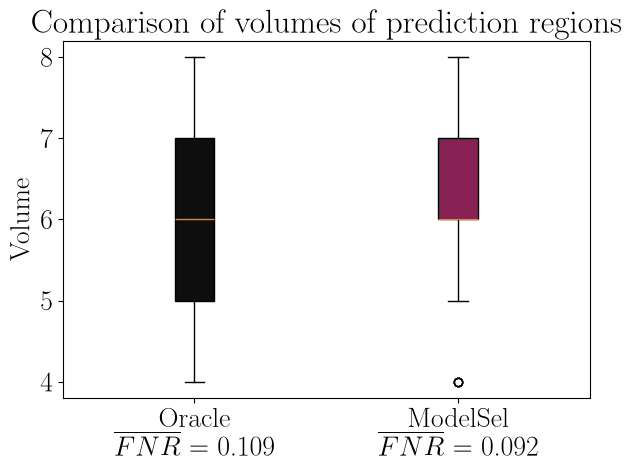

In [18]:
(oracle_fnrs, oracle_volumes,
modelSel_fnrs, modelSel_volumes) = evaluate(modelSel_prediction_sets, oracle_prediction_sets, outputs_test)

fig, ax = visulasize(
    oracle_fnrs, oracle_volumes,
    modelSel_fnrs, modelSel_volumes
)